author: Daniel Dachs

date: 13/02/2026

version: 1


Queries uniprot interpro api for information about the taxomic groups a protein is found in.

AIMS

To analyse the distribution of BLUF protein domain across life to inform a decision on selecting genomes for later analysis.

Full working code and functions used here are available in interpro_access.py

In [ ]:
from src.DarwinsRNAHunt.interpro_access import *

Protein ID can be found on interpro https://www.ebi.ac.uk/interpro/protein/UniProt/#table

In [2]:
prot_id = "IPR007024"

Download and save taxa info to file.

In [3]:
download_and_save_taxanomic_info("IPR007024")

Reload taxa information and visualise as a tree

144


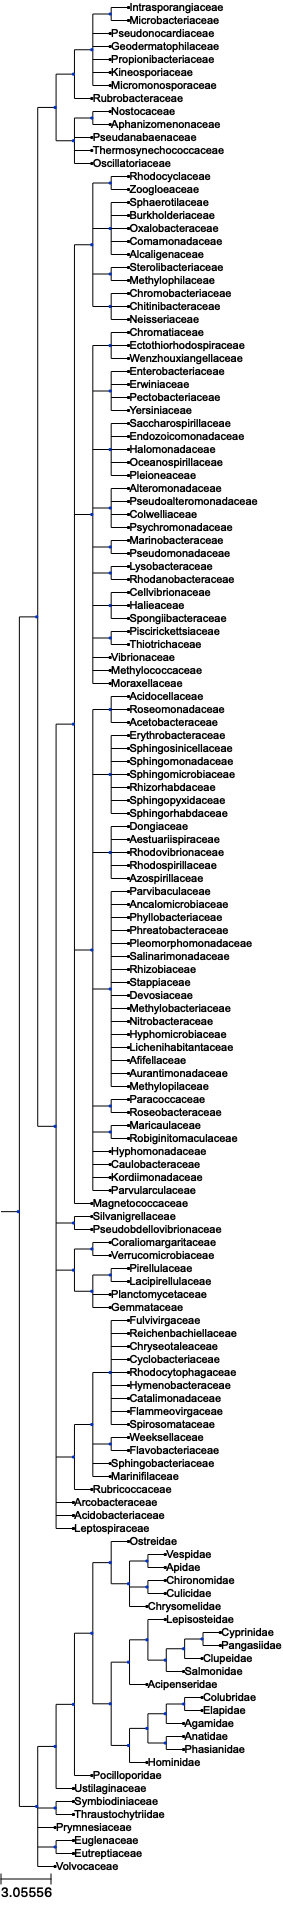

In [9]:
from ete3 import NCBITaxa

ncbi = NCBITaxa()
# List of species taxids from the data we previouly downloaded
taxa_info = load_taxonomic_info()

taxids = get_taxa_ids(taxa_info)

# Get the tree topology
tree = ncbi.get_topology(taxids)

for node in tree.traverse():
    #if node.is_leaf():
        # Get the scientific name for the TaxID
    node.name = ncbi.get_taxid_translator([int(node.name)])[int(node.name)]

families = []

for node in tree.traverse():
    rank = ncbi.get_rank([node.taxid])[node.taxid]
    if rank == "family":
        families.append(node.taxid)

family_tree = ncbi.get_topology(families)

for node in family_tree.traverse():
    #if node.is_leaf():
        # Get the scientific name for the TaxID
    node.name = ncbi.get_taxid_translator([int(node.name)])[int(node.name)]

print(len(families))

family_tree.render("%%inline")